# Title

In [81]:
# import necessary libraries
import geopandas as gpd
import pandas as pd
import os
import matplotlib as plt
import numpy as np

# statistics
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [3]:
os.environ['PROJ_LIB'] = '/opt/anaconda3/share/proj'

In [44]:
# read in data
cal = gpd.read_file("../../../../../../capstone/electrigrid/data/dis_adv_comm/calenviroscreen50_D_12226.gdb")
pge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/pge_census_map_new.parquet")
sdge = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sdge_census_map_new.parquet")
sce = gpd.read_parquet("../../../../../../capstone/electrigrid/data/census_hosting_capacity/sce_census_map_new.parquet")

## CalEnviroScreen data

In [6]:
cal.head()

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,PopOver_65,White_Pct,Hispanic_Pct,Black_Pct,NatAmeri_Pct,Asian_Pct,OtherMulti_Pct,Shape_Length,Shape_Area,geometry
0,6.001400e+09,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,29.54,68.10,6.46,4.43,0.00,14.93,6.08,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731..."
1,6.001400e+09,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,25.51,67.27,9.36,2.05,0.67,12.23,8.41,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839..."
2,6.001400e+09,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,17.62,58.76,8.68,9.15,0.37,10.63,12.41,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909..."
3,6.001400e+09,94609,Oakland,Alameda,Bay Area,4395.0,7.731604,5.903201,0.028516,4.524489,...,14.36,60.18,13.74,9.85,0.00,9.60,6.62,3801.442194,7.161367e+05,"MULTIPOLYGON (((-198758.781 -17054.583, -19875..."
4,6.001400e+09,94609,Oakland,Alameda,Bay Area,3822.0,20.223762,38.752907,0.028516,4.524489,...,15.80,44.37,14.57,23.84,0.10,8.19,8.92,3290.498854,5.914232e+05,"MULTIPOLYGON (((-199415.106 -16265.064, -19940..."


In [7]:
cal.columns

Index(['tract', 'ZIP', 'AppoxLoc', 'county', 'region', 'Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemploymen

<module 'matplotlib.colorbar' from '/Users/sarak/.conda/envs/electrigrid-env/lib/python3.11/site-packages/matplotlib/colorbar.py'>

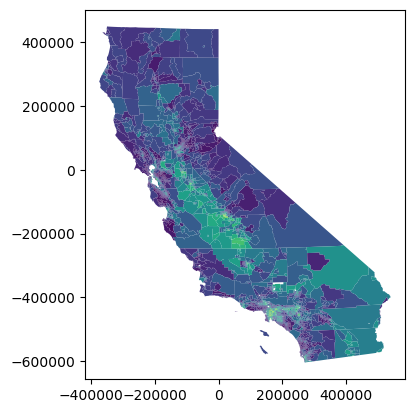

In [16]:
cal.plot(column = "CIscore")

In [18]:
cal["CIscore"].describe()

count    9029.000000
mean       28.517686
std        16.522764
min         0.587307
25%        15.086464
50%        25.111453
75%        39.699603
max        90.064558
Name: CIscore, dtype: float64

## Utility data

In [46]:
# concatenate the three utilities into one
utility = pd.concat([pge, sdge, sce])

In [17]:
utility.head()

,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry,avg_DER_total_pv_opflex_hh
0,06085507002,540.0,0.118175,1.324577,NaN,"POLYGON ((-176262.283 -88639.818, -176244.255 ...",NaN
1,06085504323,991.0,2.402836,2.031192,NaN,"POLYGON ((-167172.267 -66461.523, -167161.577 ...",NaN
2,06013381000,1003.0,NaN,NaN,NaN,"POLYGON ((-206458.778 -6405.713, -206454.212 -...",NaN
3,06085511915,817.0,7.913738,2.326095,NaN,"POLYGON ((-167584.842 -84019.005, -167550.179 ...",NaN
4,06085504322,773.0,NaN,NaN,NaN,"POLYGON ((-168194.845 -66340.992, -168088.860 ...",NaN


In [11]:
utility['avg_DER_remain_load_hh'].describe()

count    5493.000000
mean        3.977895
std        83.904706
min         0.000000
25%         0.320396
50%         0.927363
75%         2.186217
max      6132.883294
Name: avg_DER_remain_load_hh, dtype: float64

In [13]:
utility['avg_DER_remain_load_hh'].isna().sum()

3603

In [14]:
len(utility)

9096

### Stats df

Join hosting capacity to census-tract-level sociodemographic variables.

In [45]:
# change tract column in `cal` to object
cal['tract'] = cal['tract'].astype('string')

# strip decimal (.0) at the end) -- ONLY RUN ONCE
cal['tract'] = cal['tract'].str[:-2] 

# add start 0 back in -- ONLY RUN ONCE
cal['tract'] = '0' + cal['tract']

In [48]:
stats = pd.merge(cal, utility, left_on = "tract", right_on = "GEOID")

In [50]:
stats.head()

,tract,ZIP,AppoxLoc,county,region,Population,CIscore,CIscore_Pctl,AirOzone,AirOzone_Pctl,...,Shape_Length,Shape_Area,geometry_x,GEOID,zillow_tract_hh_count,avg_DER_remain_pv_hh,avg_DER_remain_load_hh,avg_DER_total_pv_hh,geometry_y,avg_DER_total_pv_opflex_hh
0,06001400100,94720,Berkeley,Alameda,Bay Area,3094.0,9.786846,10.388747,0.029251,6.028992,...,14229.013451,6.945853e+06,"MULTIPOLYGON (((-197333.073 -12225.564, -19731...",06001400100,412.0,0.070207,1.711574,NaN,"POLYGON ((-197333.073 -12225.563, -197310.342 ...",NaN
1,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,408.0,NaN,NaN,NaN,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
2,06001400200,94618,Oakland,Alameda,Bay Area,2093.0,7.181343,4.817809,0.028516,4.524489,...,3998.017070,5.865583e+05,"MULTIPOLYGON (((-198413.266 -16953.512, -19839...",06001400200,185.0,1.245549,0.533618,1.503659,"POLYGON ((-198413.266 -16953.512, -198395.570 ...",NaN
3,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,1434.0,NaN,NaN,NaN,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN
4,06001400300,94618,Oakland,Alameda,Bay Area,5727.0,12.907937,18.972201,0.028516,4.524489,...,5317.707207,1.110836e+06,"MULTIPOLYGON (((-199103.674 -17489.695, -19909...",06001400300,994.0,1.571644,0.001033,1.727566,"POLYGON ((-199103.674 -17489.695, -199097.315 ...",NaN


## Basic linear regression

In [70]:
# drop rows with NAs
stats_clean = stats.dropna()

In [72]:
len(stats)

9096

In [68]:
len(stats_clean)

8908

<Axes: ylabel='Frequency'>

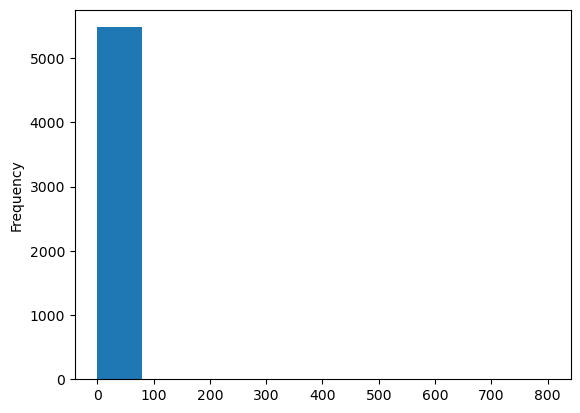

In [94]:
stats['avg_DER_remain_pv_hh'].plot(kind = "hist")

In [93]:
# initialize model
model_lm = LinearRegression()

# predictor variables (retrieved from cal.columns)
X =stats_clean[['Population', 'CIscore',
       'CIscore_Pctl', 'AirOzone', 'AirOzone_Pctl', 'AirPM25', 'AirPM25_Pctl',
       'ChildLead', 'ChildLead_Pctl', 'DieselPM', 'DieselPM_Pctl',
       'DrinkingWater', 'DrinkingWater_Pctl', 'Pesticides', 'Pesticides_Pctl',
       'ToxReleases', 'ToxReleases_Pctl', 'TrafficImp', 'TrafficImp_Pctl',
       'CleanupSites', 'CleanupSites_Pctl', 'gwthreats', 'GWThreats_Pctl',
       'HazWaste', 'HazWaste_Pctl', 'ImpWaters', 'ImpWaters_Pctl',
       'SmAirToxSites', 'SmAirToxSites_Pctl', 'SolidWaste', 'SolidWaste_Pctl',
       'Pollution', 'PollutionScore', 'Pollution_Pctl', 'asthma',
       'Asthma_Pctl', 'Cardiovascular', 'Cardiovascular_Pctl', 'DiabetesPrev',
       'DiabetesPrev_Pctl', 'LowBirthWeight', 'LowBirthWeight_Pctl',
       'Education', 'Education_Pctl', 'HousingBurden', 'HousingBurden_Pctl',
       'LinguisticIso', 'LinguisticIso_Pctl', 'Poverty', 'Poverty_Pctl',
       'Unemployment', 'Unemployment_Pctl', 'PopChar', 'PopCharScore',
       'PopChar_Pctl', 'PopUnd_10', 'Pop10_64', 'PopOver_65', 'White_Pct',
       'Hispanic_Pct', 'Black_Pct', 'NatAmeri_Pct', 'Asian_Pct',
       'OtherMulti_Pct']]

y = stats_clean['avg_DER_remain_pv_hh']

# split data into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state= 42) # need stratify?

# fit the scaler ONLY to X test (don't scale testing data)
scaler = StandardScaler().fit(X_train)

# create scaled versions of training data
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

In [83]:
# fit model
model_lm.fit(X_train, y_train)

# predict y
y_pred = model_lm.predict(X_test)

# Calculate MSE and R^2 for Ridge regression
lm_mse = mean_squared_error(y_test, y_pred)

In [84]:
lm_mse

10.466913708294303

### Lasso regression
To find which predictors are actually relevant

In [85]:
# initialize and fit model
lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)


# Calculate MSE and R^2 for Lasso regression
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)



print("Lasso Regression MSE:", lasso_mse)
print("Lasso Regression R²:", lasso_r2)

Lasso Regression MSE: 10.445571896964418
Lasso Regression R²: 0.05334861379250855


In [90]:
# Create and fit Ridge regression model
ridge_model = Ridge()
ridge_model.fit(X_train, y_train)

# Generate predictions
ridge_predictions = ridge_model.predict(X_test)

# Calculate MSE and R^2 for Ridge regression
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression MSE:", ridge_mse)
print("Ridge Regression R²:", ridge_r2)

Ridge Regression MSE: 10.17667162060802
Ridge Regression R²: 0.0777182530880206
